In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from matplotlib import pyplot as plt

SEED = 42
np.random.seed(SEED)

columns = ["survival", "socialization", "self_realization", "aggregated"]
colors = ["blue", "darkorange", "green", "magenta"]
labels = ["Hit probability (F1 > 0.75)"] * 3 + ["Aggregated predictability"]

folder_type = "raif"  #  "trans_34k"  "transact_10k"

processed_folder = Path(f"processed_data/{folder_type}")
results_folder = Path(f"results/{folder_type}")

transactions = [
    f
    for f in processed_folder.iterdir()
    if f.is_file()
    and not f.name.endswith("_lzc.csv")
    and not f.name.endswith("_huffman.csv")
]
lzc_files = [
    f for f in processed_folder.iterdir() if f.is_file() and f.name.endswith("_lzc.csv")
]
huffman_files = [
    f
    for f in processed_folder.iterdir()
    if f.is_file() and f.name.endswith("_huffman.csv")
]
hp_files = [f for f in results_folder.iterdir() if f.is_file()]

_ = transactions.sort(), hp_files.sort(), lzc_files.sort(), huffman_files.sort()

In [2]:
def match_hp_files(hp_files, files, hp_postfix, files_postfix):
    exact_names = []
    existing_files = []

    for item in hp_files:
        exact_names.append(item.name[: -len(hp_postfix)])

    for item in files:
        if item.name[: -len(files_postfix)] in exact_names:
            existing_files.append(item)

    return existing_files

In [3]:
lzc_files = match_hp_files(
    hp_files=hp_files,
    files=lzc_files,
    hp_postfix="_results.csv",
    files_postfix="_lzc.csv",
)
huffman_files = match_hp_files(
    hp_files=hp_files,
    files=huffman_files,
    hp_postfix="_results.csv",
    files_postfix="_huffman.csv",
)

In [4]:
def load_dataframe(files, index_cols):
    loaded_df = None
    for file in files:
        tmp_df = pd.read_csv(file, index_col=index_cols)
        if loaded_df is None:
            loaded_df = tmp_df
        else:

            loaded_df = pd.concat([loaded_df, tmp_df], ignore_index=False)

    return loaded_df

In [5]:
transact_df = load_dataframe(transactions, index_cols=["client", "date"])
print(
    (
        len(transact_df["survival"]),
        sum(transact_df["survival"] > 0),
        sum(transact_df["socialization"] > 0),
        sum(transact_df["self_realization"] > 0),
    )
)
# del transact_df

(1823412, 387860, 87399, 52823)


In [6]:
sssr_hp_df = load_dataframe(hp_files, index_cols="id").round(3)
lz_df = load_dataframe(lzc_files, index_cols="client")
huffman_df = load_dataframe(huffman_files, index_cols="client")

In [7]:
huffman_df["huffman_ratio_code"]

client
0       0.628415
1       0.389800
2       0.741348
3       0.479053
4       0.664845
          ...   
9981    0.336976
9982    0.338798
9983    0.335155
9984    0.336976
9986    0.335155
Name: huffman_ratio_code, Length: 9964, dtype: float64

In [8]:
sssr_hp_df["aggregated"] = np.sqrt((sssr_hp_df[columns[:3]] ** 2).sum(axis=1) / 3.0)

for col in columns[:3]:
    lz_df["log_" + col] = np.log10(lz_df[col])
    lz_df["sqrt_" + col] = np.sqrt(lz_df[col])

huffman_df["log_code"] = np.log10(huffman_df["huffman_ratio_code"])

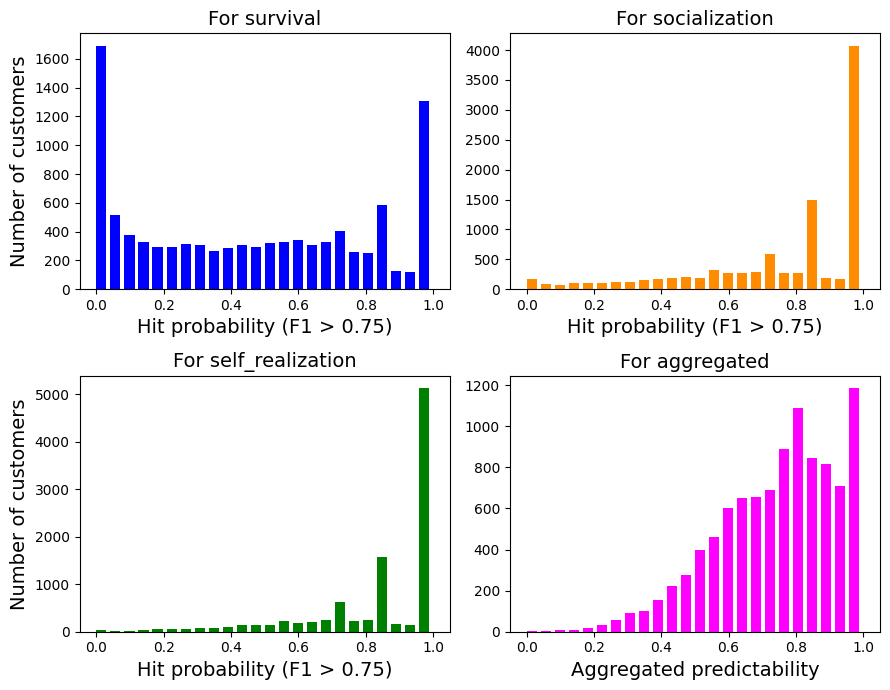

In [9]:
x = np.linspace(-0.0, 1.0, 25)

plt.figure(figsize=(9, 7))
for i, j in enumerate(zip(columns, colors, labels)):
    plt.subplot(2, 2, i + 1)
    plt.title("For " + j[0], size=14)
    plt.hist(sssr_hp_df[j[0]], x, width=0.03, color=j[1], align="mid")
    plt.xlabel(j[2], size=14)
    if not i % 2:
        plt.ylabel("Number of customers", size=14)
plt.tight_layout()
plt.show()

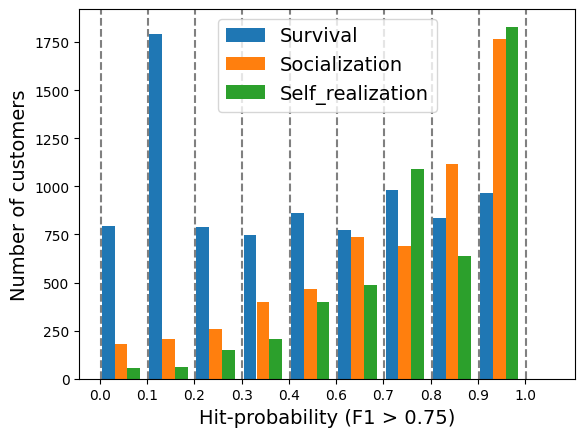

In [10]:
x = np.linspace(-0.0, 1.0, 10)
for i, v in enumerate(columns[:3]):
    plt.hist(
        sssr_hp_df[v] + 0.1, x + i / 33.3, width=0.03, label=v.capitalize(), align="mid"
    )
for i in x[:]:
    plt.axvline(i - 0.003, ls="--", c="gray")
plt.legend(fontsize=14)
plt.xticks(x[:] - 0.005, (x[:]).round(1))
plt.xlabel("Hit-probability (F1 > 0.75)", size=14)
plt.ylabel("Number of customers", size=14)
plt.show()

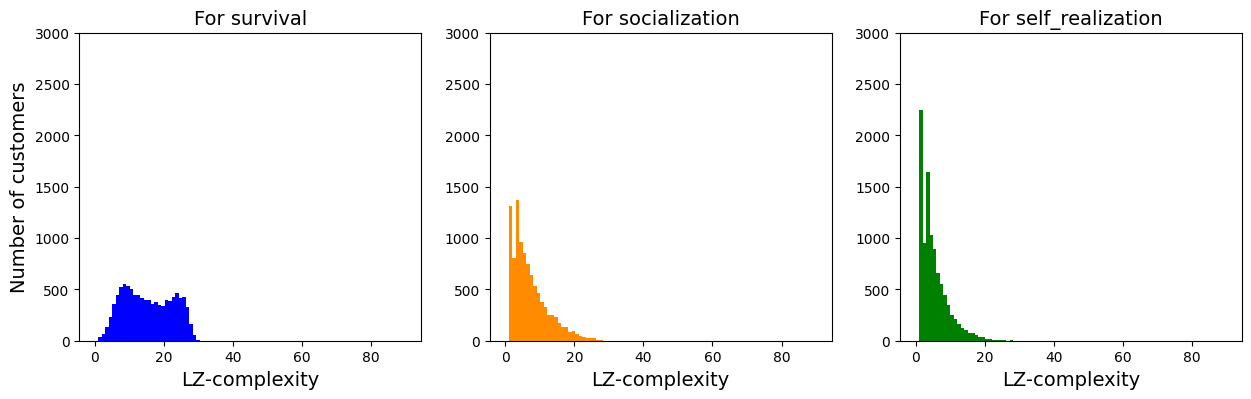

In [11]:
x = np.linspace(-0.0, 90.0, 90)
plt.figure(figsize=(15, 4))
for i, (col, color, label) in enumerate(zip(columns[:3], colors[:3], labels[:3])):
    plt.subplot(1, 3, i + 1)
    plt.title("For " + col, size=14)
    plt.hist(lz_df[col], x, color=color)
    plt.xlabel("LZ-complexity", size=14)
    plt.ylim((0, 3000))
    if not i % 3:
        plt.ylabel("Number of customers", size=14)
plt.show()

In [12]:
def plot(
    x_df,
    y_df,
    x_cols,
    y_cols,
    colors,
    labels,
    figsize,
    subplot,
    label_period,
    xlabel,
    title,
    xlim=None,
):
    plt.figure(figsize=figsize)

    for i, (x_col, y_col, color, label) in enumerate(
        zip(x_cols, y_cols, colors, labels)
    ):
        plt.subplot(*subplot, i + 1)
        plt.scatter(x_df[x_col], y_df[y_col], color=color, alpha=0.6, s=25)

        plt.title(f"{title} {y_col}", size=14)
        plt.xlabel(xlabel, size=14)
        if i % label_period == 0:
            plt.ylabel(label, size=14)
        if xlim:
            plt.xlim(*xlim)

    plt.tight_layout()
    plt.show()


def correlation(a_df, b_df, a_cols, b_cols, title):
    print(title)
    print("\t\t\t", end="")
    for a_col, b_col in zip(a_cols, b_cols):
        corr = a_df[a_col].corr(b_df[b_col], method="spearman")
        print(f"{b_col}: {corr:.3f}; ", end="")
    print()

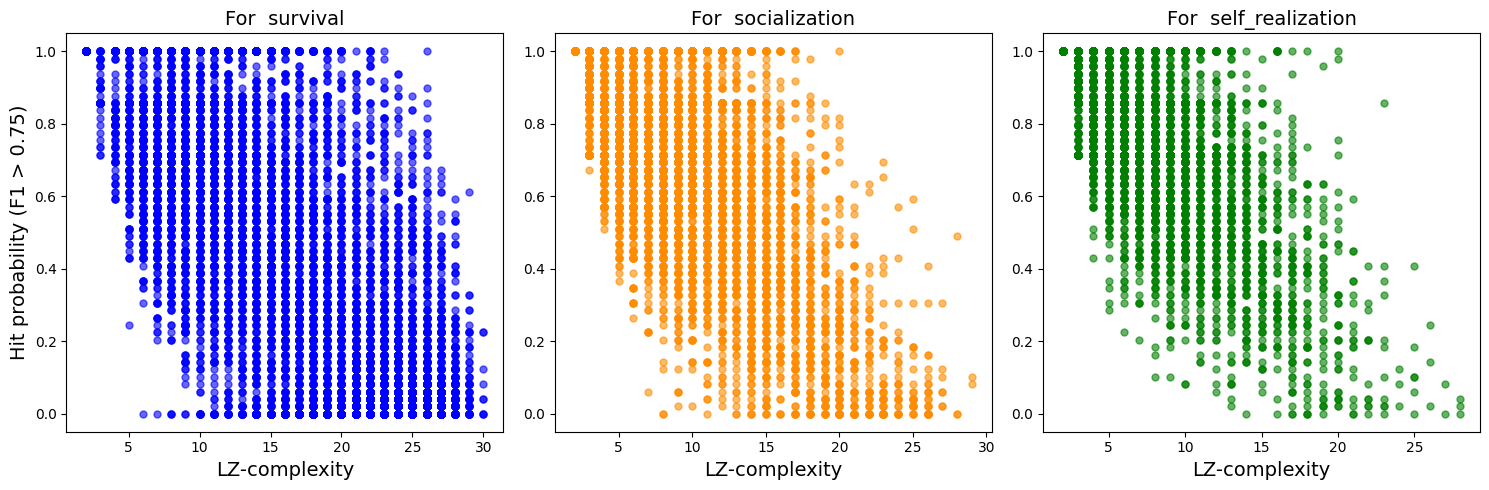

In [13]:
plot(
    x_df=lz_df,
    y_df=sssr_hp_df,
    x_cols=columns[:3],
    y_cols=columns[:3],
    colors=colors[:3],
    labels=labels[:3],
    figsize=(15, 5),
    subplot=(1, 3),
    label_period=3,
    xlabel="LZ-complexity",
    title="For ",
)

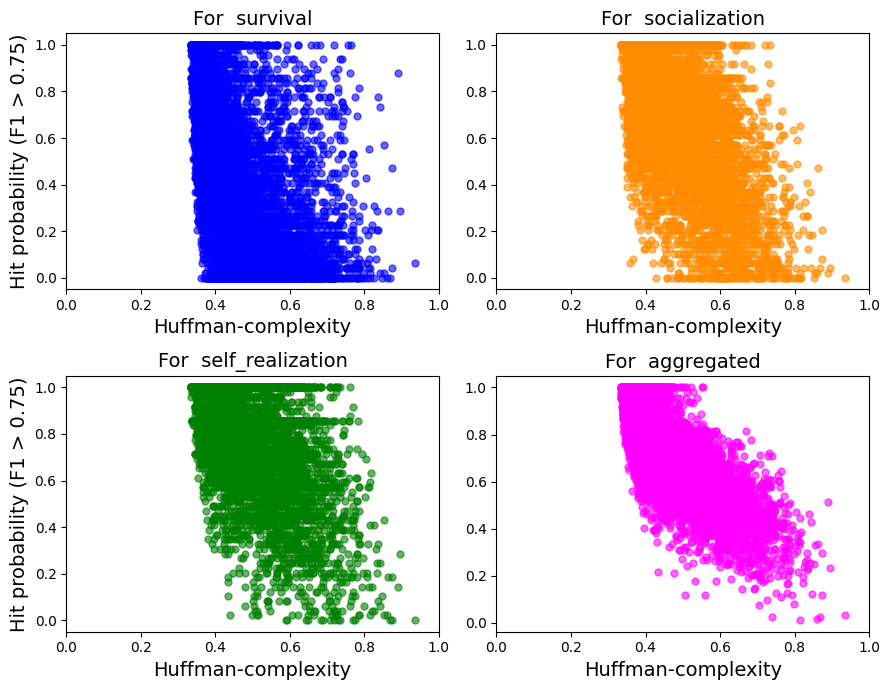

In [14]:
plot(
    x_df=huffman_df,
    y_df=sssr_hp_df,
    x_cols=["huffman_ratio_code"] * 4,
    y_cols=columns,
    colors=colors,
    labels=labels,
    figsize=(9, 7),
    subplot=(2, 2),
    label_period=2,
    xlabel="Huffman-complexity",
    title="For ",
    xlim=(0, 1),
)

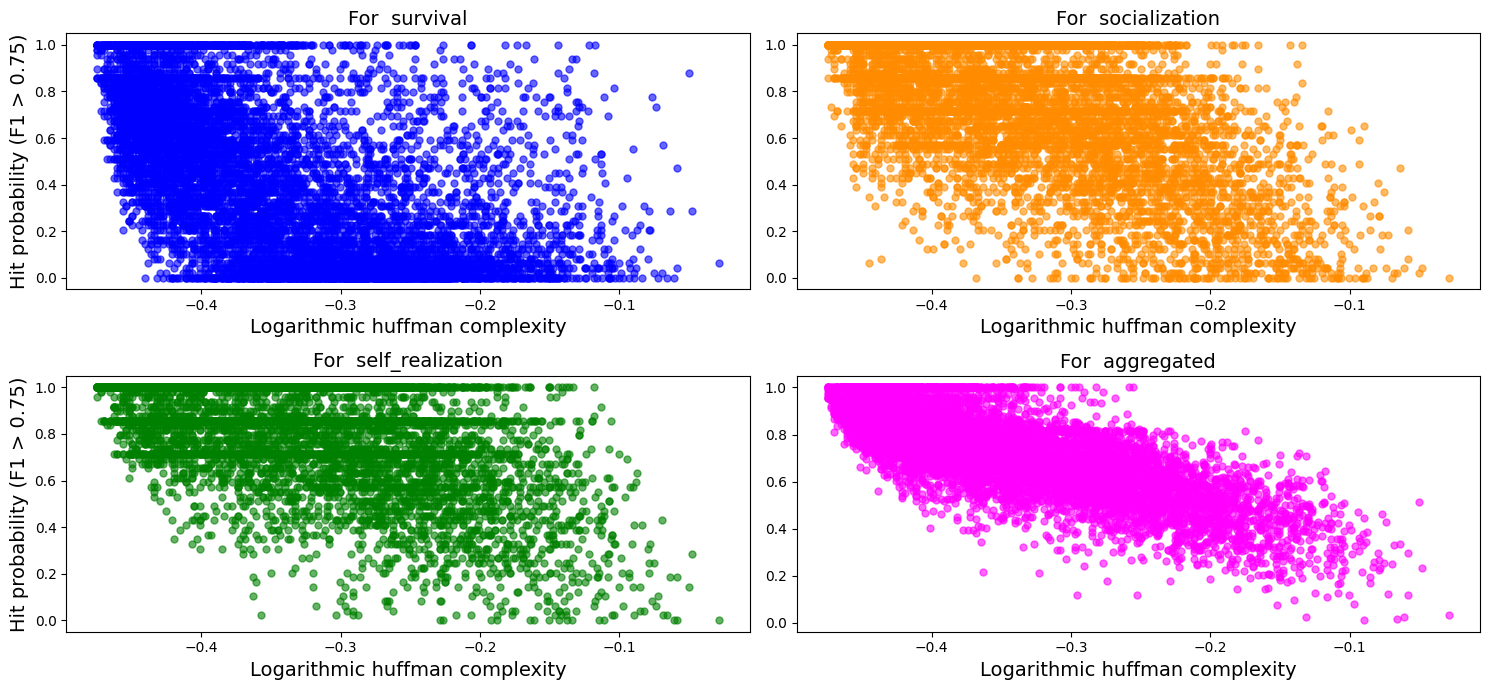

In [15]:
plot(
    x_df=huffman_df,
    y_df=sssr_hp_df,
    x_cols=["log_code"] * 4,
    y_cols=columns,
    colors=colors,
    labels=labels,
    figsize=(15, 7),
    subplot=(2, 2),
    label_period=2,
    xlabel="Logarithmic huffman complexity",
    title="For ",
)

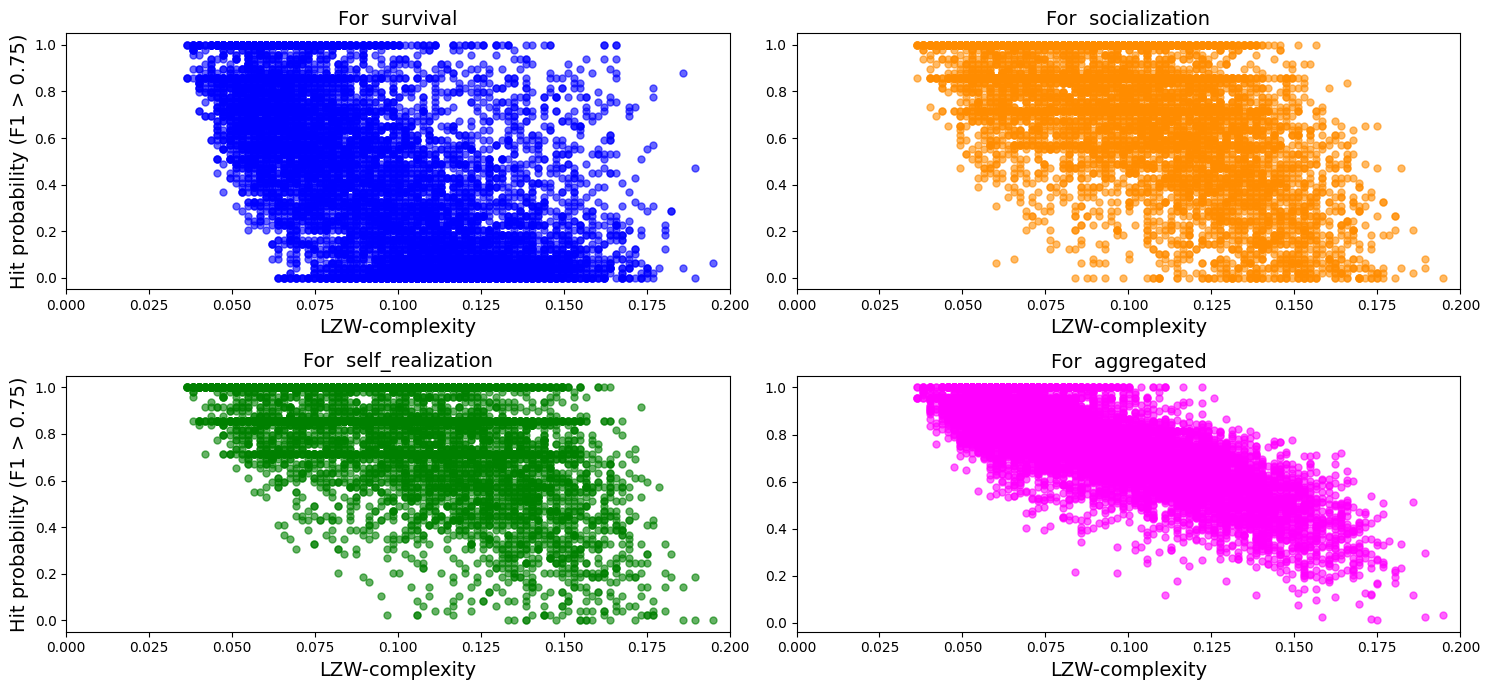

In [16]:
plot(
    x_df=lz_df,
    y_df=sssr_hp_df,
    x_cols=["LZW"] * 4,
    y_cols=columns,
    colors=colors,
    labels=labels,
    figsize=(15, 7),
    subplot=(2, 2),
    label_period=2,
    xlabel="LZW-complexity",
    title="For ",
    xlim=(0, 0.2),
)

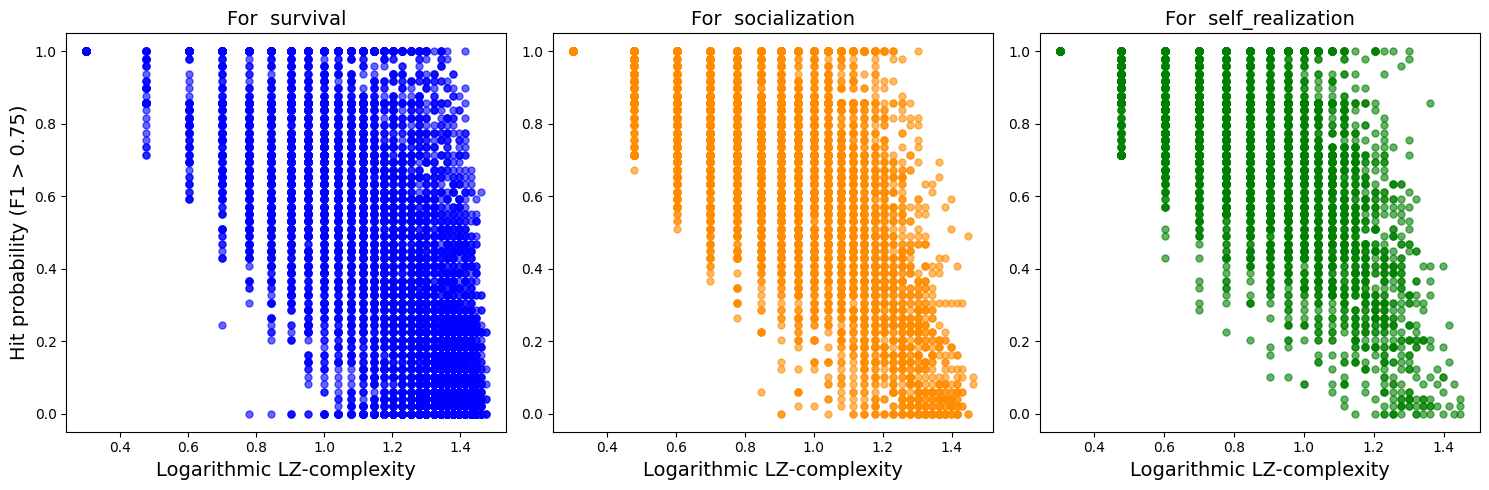

In [17]:
plot(
    x_df=lz_df,
    y_df=sssr_hp_df,
    x_cols=["log_" + i for i in columns[:3]],
    y_cols=columns[:3],
    colors=colors[:3],
    labels=labels[:3],
    figsize=(15, 5),
    subplot=(1, 3),
    label_period=3,
    xlabel="Logarithmic LZ-complexity",
    title="For ",
)

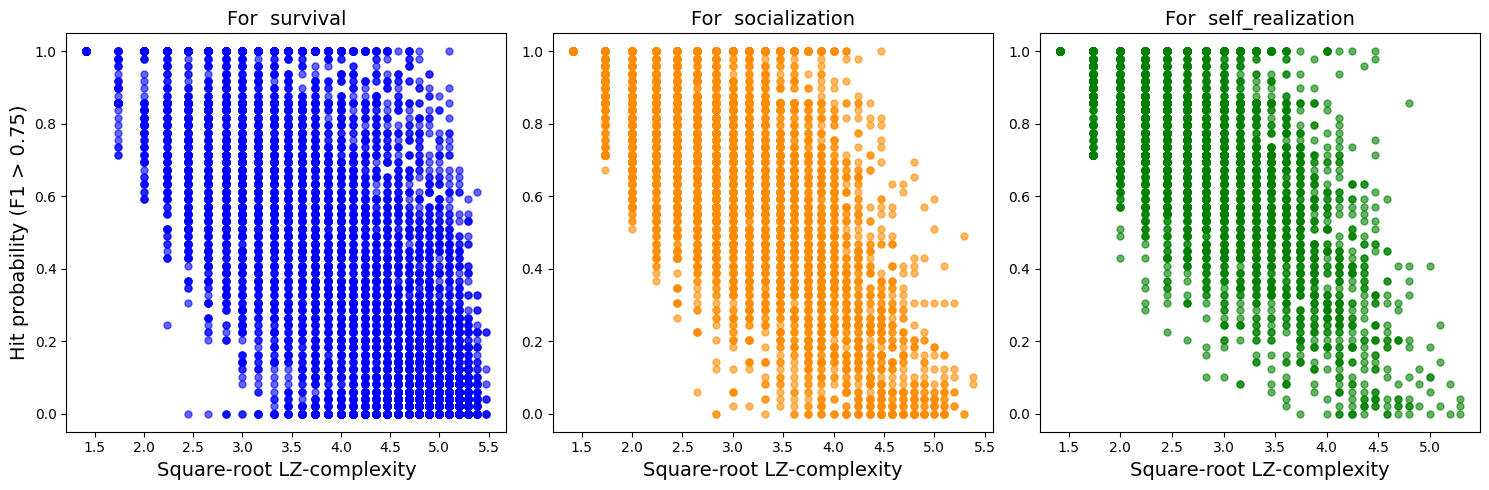

In [18]:
plot(
    x_df=lz_df,
    y_df=sssr_hp_df,
    x_cols=["sqrt_" + i for i in columns[:3]],
    y_cols=columns[:3],
    colors=colors[:3],
    labels=labels[:3],
    figsize=(15, 5),
    subplot=(1, 3),
    label_period=3,
    xlabel="Square-root LZ-complexity",
    title="For ",
)

In [19]:
correlation(
    a_df=lz_df,
    b_df=sssr_hp_df,
    a_cols=columns[:3],
    b_cols=columns[:3],
    title="LZ correlation: ",
)
correlation(
    a_df=huffman_df,
    b_df=sssr_hp_df,
    a_cols=["huffman_ratio_code"] * 4,
    b_cols=columns,
    title="Huffman correlation: ",
)
correlation(
    a_df=lz_df,
    b_df=sssr_hp_df,
    a_cols=["LZW"] * 4,
    b_cols=columns,
    title="LZW correlation: ",
)

correlation(
    a_df=lz_df,
    b_df=sssr_hp_df,
    a_cols=["log_" + i for i in columns[:3]],
    b_cols=columns[:3],
    title="Logarithmic LZ correlation: ",
)
correlation(
    a_df=lz_df,
    b_df=sssr_hp_df,
    a_cols=["sqrt_" + i for i in columns[:3]],
    b_cols=columns[:3],
    title="Square root LZ correlation: ",
)
correlation(
    a_df=huffman_df,
    b_df=sssr_hp_df,
    a_cols=["log_code"] * 4,
    b_cols=columns,
    title="Huffman logarithmic correlation: ",
)

LZ correlation: 
			survival: -0.698; socialization: -0.699; self_realization: -0.677; 
Huffman correlation: 
			survival: -0.659; socialization: -0.618; self_realization: -0.572; aggregated: -0.789; 
LZW correlation: 
			survival: -0.663; socialization: -0.617; self_realization: -0.562; aggregated: -0.791; 
Logarithmic LZ correlation: 
			survival: -0.698; socialization: -0.699; self_realization: -0.677; 
Square root LZ correlation: 
			survival: -0.698; socialization: -0.699; self_realization: -0.677; 
Huffman logarithmic correlation: 
			survival: -0.659; socialization: -0.618; self_realization: -0.572; aggregated: -0.789; 


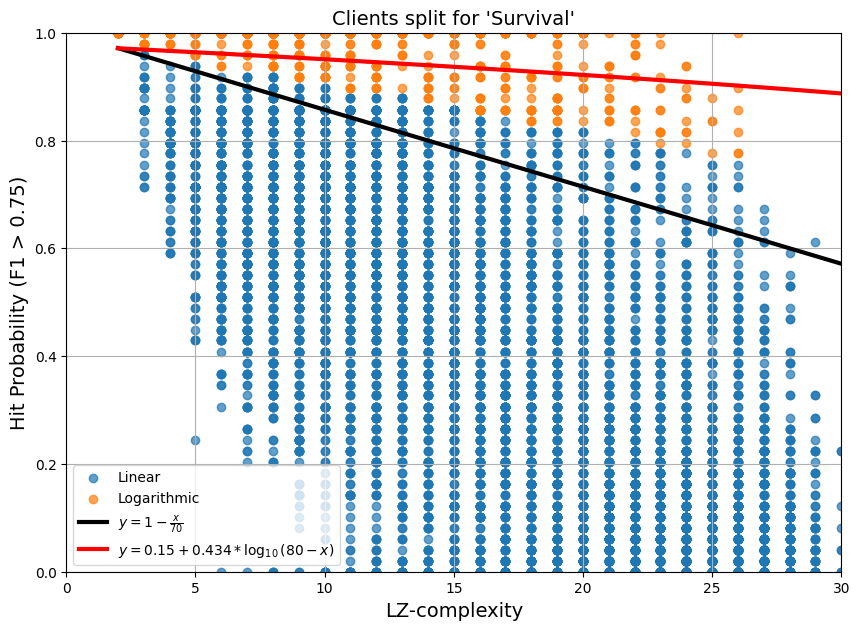

In [20]:
def linear_component(x):
    x = np.asarray(x)
    return 1 - x / 70


def log_component(x):
    x = np.asarray(x)
    x = np.clip(x, None, 79.999)
    return 0.15 + 0.434 * np.log10(80 - x)
    # return np.log(-x + 80) / np.log(200) + 0.15


def split_clients(x, y):
    X, Y = x.values, y.values
    y_line = linear_component(X)
    y_log = log_component(X)

    dist_line, dist_log = np.abs(Y - y_line), np.abs(Y - y_log)
    to_log = (dist_log < dist_line) | (Y > y_log)
    to_line = ~to_log
    return to_line, to_log


def plot_split(x, y, to_line, to_log):
    plt.figure(figsize=(10, 7))
    plt.scatter(x[to_line], y[to_line], label="Linear", alpha=0.7)
    plt.scatter(x[to_log], y[to_log], label="Logarithmic", alpha=0.7)
    x_grid = np.linspace(x.min(), x.max(), int(x.max()))
    plt.plot(
        x_grid,
        linear_component(x_grid),
        linewidth=3,
        color="black",
        label=r"$y = 1 - \frac{x}{70}$",
    )
    plt.plot(
        x_grid,
        log_component(x_grid),
        linewidth=3,
        color="red",
        label=r"$y = 0.15 + 0.434 * \log_{10}(80 - x)$",
    )
    plt.legend()
    plt.xlim(0, x.max())
    plt.ylim(0, 1)
    plt.grid()
    plt.title("Clients split for 'Survival'", size=14)
    plt.xlabel("LZ-complexity", size=14)
    plt.ylabel("Hit Probability (F1 > 0.75)", size=14)
    plt.show()


to_line, to_log = split_clients(lz_df["survival"], sssr_hp_df["survival"])
plot_split(lz_df["survival"], sssr_hp_df["survival"], to_line, to_log)

In [21]:
linear_clients_transactions = transact_df[
    transact_df.index.get_level_values(0).isin(sssr_hp_df[to_line].index)
]
log_clients_transactions = transact_df[
    transact_df.index.get_level_values(0).isin(sssr_hp_df[to_log].index)
]

In [22]:
print(
    (
        len(linear_clients_transactions["survival"]),
        sum(linear_clients_transactions["survival"] > 0),
        sum(linear_clients_transactions["socialization"] > 0),
        sum(linear_clients_transactions["self_realization"] > 0),
    )
)
print(
    (
        len(log_clients_transactions["survival"]),
        sum(log_clients_transactions["survival"] > 0),
        sum(log_clients_transactions["socialization"] > 0),
        sum(log_clients_transactions["self_realization"] > 0),
    )
)

(1545801, 353230, 79128, 48137)
(277611, 34630, 8271, 4686)


In [23]:
print(
    sum(linear_clients_transactions["survival"] > 0)
    / len(linear_clients_transactions["survival"]),
    sum(linear_clients_transactions["socialization"] > 0)
    / len(linear_clients_transactions["socialization"]),
    sum(linear_clients_transactions["self_realization"] > 0)
    / len(linear_clients_transactions["self_realization"]),
)
print(
    sum(log_clients_transactions["survival"] > 0)
    / len(log_clients_transactions["survival"]),
    sum(log_clients_transactions["socialization"] > 0)
    / len(log_clients_transactions["socialization"]),
    sum(log_clients_transactions["self_realization"] > 0)
    / len(log_clients_transactions["self_realization"]),
)

0.2285093618130665 0.051188995219953924 0.03114048962317918
0.12474289563453898 0.029793488010201326 0.016879734592649426
